# IMPORTS

In [1]:
%load_ext autoreload

import os
os.environ["JAX_PLATFORM_NAME"] = "cpu"

import jax.numpy as jnp

import tol_colors as tc
import matplotlib.pyplot as plt
import plotting_tools.basic_plotting_tools as pts
colors = pts.set_plot_style(default_cmap=tc.sunset)
%matplotlib widget

In [2]:
import differential_geometry.manifolds as manifolds
import differential_geometry.aux_manifolds as aux_manifolds
import plotting_tools.plot_manifolds as plot_manifolds

from scipy.spatial import Delaunay
import differential_geometry.charts as charts
import differential_geometry.aux_charts as aux_charts
import plotting_tools.plot_charts as plot_charts

import differential_geometry.functions as functions
import plotting_tools.plot_functions as plot_functions

import differential_geometry.curves as curves
import differential_geometry.aux_curves as aux_curves
import plotting_tools.plot_curves as plot_curves

# 2D-mfd embedded in 3D

Example of Appendix *Example of $T_p\mathcal{M}$*: $\mathcal{M} = \mathbb{R}^2$ with the two global charts
$\mathscr{X}(q) = (2q_1, -q_2)$ and $\mathscr{Y}(q) = (q_1, q_2 e^{q_1})$, the curves
$\gamma_1(\lambda) = (\lambda, 1)$ and $\gamma_2(\lambda) = (1, 2\lambda)$ through $p = (1, 1)$, and their sums
$\sigma_\mathcal{U}$ and $\sigma_\mathcal{V}$ built inside each chart.

In [3]:
def embedding(params, z0=1.0):
    x, y = params
    return jnp.array([x, y, z0])

manifold = manifolds.Manifold(
    name=r"$\mathcal{M}$", dim=2, ambient_dim=3,
    embedding_func=embedding, # embedding_func=aux_manifolds.factory_surface_embedding_gaussian_eggs(amplitude=1.0, center=(0.0, 0.0), sigma=(jnp.pi, jnp.pi)),
)

# === Chart maps of the example ===
# (U, X):  X(q) = (2 q_1, -q_2)
def chart_map_X(params):
    return jnp.stack([2.0 * params[..., 0], -params[..., 1]], axis=-1)

def inverse_chart_map_X(chart_coords):
    return jnp.stack([chart_coords[..., 0] / 2.0, -chart_coords[..., 1]], axis=-1)

# (V, Y):  Y(q) = (q_1, q_2 exp(q_1))
def chart_map_Y(params):
    return jnp.stack([params[..., 0], params[..., 1] * jnp.exp(params[..., 0])], axis=-1)

def inverse_chart_map_Y(chart_coords):
    return jnp.stack([chart_coords[..., 0], chart_coords[..., 1] * jnp.exp(-chart_coords[..., 0])], axis=-1)

# === Chart domains: both charts are global (U = V = M). For plotting purposes the
# === domains are represented by the parameter-space window shown in the figures.
lambdas = jnp.linspace(0, 4, 1000, endpoint=False)
boundary_U = aux_charts.boundary_rectangle_in_param_space(lambdas, xlim=(0, 2), ylim=(0, 2))
boundary_V = aux_charts.boundary_rectangle_in_param_space(lambdas, xlim=(0, 2), ylim=(0, 2))

chart_U = charts.Chart(
    name="U", manifold=manifold, boundary=jnp.array(boundary_U), chart_map=chart_map_X,
    inverse_chart_map=inverse_chart_map_X,
    region_sampler=aux_charts.polar_region_sampler_from_boundary(jnp.array(boundary_U))
)

chart_V = charts.Chart(
    name="V", manifold=manifold, boundary=jnp.array(boundary_V), chart_map=chart_map_Y,
    inverse_chart_map=inverse_chart_map_Y,
    region_sampler=aux_charts.polar_region_sampler_from_boundary(jnp.array(boundary_V))
)


boundary_U_cap_V = aux_charts.compute_chart_intersection(boundary_U, boundary_V)

chart_U_cap_V_X = charts.Chart(
    name="U_cap_V_X", manifold=manifold, boundary=jnp.array(boundary_U_cap_V),
    chart_map=chart_map_X, inverse_chart_map=inverse_chart_map_X,
    region_sampler=aux_charts.polar_region_sampler_from_boundary(jnp.array(boundary_U_cap_V))
)

chart_U_cap_V_Y = charts.Chart(
    name="U_cap_V_Y", manifold=manifold, boundary=jnp.array(boundary_U_cap_V),
    chart_map=chart_map_Y, inverse_chart_map=inverse_chart_map_Y,
    region_sampler=aux_charts.polar_region_sampler_from_boundary(jnp.array(boundary_U_cap_V))
)


def my_function(params):
    x, y = params
    param_points = jnp.stack([x.ravel(), y.ravel()], axis=-1)
    tmp_ = manifold.embed(param_points)
    tmp_x = tmp_[:, 0].reshape(x.shape)
    tmp_y = tmp_[:, 1].reshape(y.shape)
    tmp_z = tmp_[:, 2].reshape(x.shape)
    return tmp_z  * jnp.sqrt(tmp_x**2 + tmp_y**2 + 2.)

function_f = functions.Function(
    manifold=manifold,
    function_parametric=my_function
)



p_x, p_y = 1.0, 1.0
p_param = jnp.array([p_x, p_y])
p_in_M = manifold.embed(p_param)



# === The two curves of the example, and the parameters at which they pass through p ===
def gamma_1(lmb):
    """gamma_1(lambda) = (lambda, 1)"""
    return jnp.stack([lmb, jnp.ones_like(lmb)])

def gamma_2(lmb):
    """gamma_2(lambda) = (1, 2 lambda)"""
    return jnp.stack([jnp.ones_like(lmb), 2.0 * lmb])

lambda_1, lambda_2 = 1.0, 0.5

# === Sum of two curves inside a chart, exactly as in the appendix:
# === sigma(lambda) = X^{-1}( X(gamma_1(lambda_1 + lambda)) + X(gamma_2(lambda_2 + lambda)) - X(p) )
def factory_curve_sum_in_chart(chart_map, inverse_chart_map, curve_1, lambda_1, curve_2, lambda_2, point):
    def sigma(lmb):
        chart_sum = (
            chart_map(curve_1(lambda_1 + lmb))
            + chart_map(curve_2(lambda_2 + lmb))
            - chart_map(point)
        )
        return inverse_chart_map(chart_sum)
    return sigma

curve_gamma1 = curves.Curve(manifold=manifold, parametric_function=gamma_1)
curve_gamma2 = curves.Curve(manifold=manifold, parametric_function=gamma_2)
curve_sigma_U = curves.Curve(
    manifold=manifold, parametric_function=factory_curve_sum_in_chart(
        chart_map_X, inverse_chart_map_X, gamma_1, lambda_1, gamma_2, lambda_2, p_param
    )
)
curve_sigma_V = curves.Curve(
    manifold=manifold, parametric_function=factory_curve_sum_in_chart(
        chart_map_Y, inverse_chart_map_Y, gamma_1, lambda_1, gamma_2, lambda_2, p_param
    )
)

# === Parameter ranges, chosen so that every curve stays inside the plotted window ===
lambda_range_gamma1 = (-0.2, 2.0)      # gamma_1(1)   = p
lambda_range_gamma2 = (-0.2, 1.1)      # gamma_2(1/2) = p
lambda_range_sigma_U = (-0.6, 0.6)     # sigma_U(0)   = p
lambda_range_sigma_V = (-0.4, 0.8)    # sigma_V(0)   = p

ERROR:2026-09-23 20:54:09,983:jax._src.xla_bridge:444: Jax plugin configuration error: Exception when calling jax_plugins.xla_cuda12.initialize()
Traceback (most recent call last):
  File "/home/dlopez/.miniconda3/envs/diff_geom/lib/python3.10/site-packages/jax_plugins/xla_cuda12/__init__.py", line 197, in _version_check
    version = get_version()
RuntimeError: jaxlib/cuda/versions_helpers.cc:81: operation cusparseGetProperty(MAJOR_VERSION, &major) failed: The cuSPARSE library was not found.

The above exception was the direct cause of the following exception:

Traceback (most recent call last):
  File "/home/dlopez/.miniconda3/envs/diff_geom/lib/python3.10/site-packages/jax/_src/xla_bridge.py", line 442, in discover_pjrt_plugins
    plugin_module.initialize()
  File "/home/dlopez/.miniconda3/envs/diff_geom/lib/python3.10/site-packages/jax_plugins/xla_cuda12/__init__.py", line 324, in initialize
    _check_cuda_versions(raise_on_first_error=True)
  File "/home/dlopez/.miniconda3/envs/

## Sum of the curves in each chart

$\sigma_\mathcal{U}$ and $\sigma_\mathcal{V}$ are different curves, but they define the same element of $T_p\mathcal{M}$:
$v_{\sigma_\mathcal{U}, p} = v_{\sigma_\mathcal{V}, p} = v_{\gamma_1, p} \oplus_T v_{\gamma_2, p}$.

In [4]:
import jax

lam = jnp.array(0.7)
print("=== closed forms of the appendix ===")
print("sigma_U(0.7) =", curve_sigma_U.parametric_function(lam), " vs  (lam + 1, 2 lam + 1)          =", jnp.array([lam + 1, 2 * lam + 1]))
print("sigma_V(0.7) =", curve_sigma_V.parametric_function(lam), " vs  (lam + 1, 1 + 2 lam e^{-lam}) =", jnp.array([lam + 1, 1 + 2 * lam * jnp.exp(-lam)]))

print("\n=== all curves pass through p ===")
print("gamma_1(lambda_1) =", gamma_1(lambda_1), "  gamma_2(lambda_2) =", gamma_2(lambda_2))
print("sigma_U(0)        =", curve_sigma_U.parametric_function(0.), "  sigma_V(0)        =", curve_sigma_V.parametric_function(0.))

print("\n=== velocities at p (components w.r.t. the parameter space) ===")
print("gamma_1'(lambda_1) + gamma_2'(lambda_2) =", jax.jacrev(gamma_1)(lambda_1) + jax.jacrev(gamma_2)(lambda_2))
print("sigma_U'(0)                             =", jax.jacrev(curve_sigma_U.parametric_function)(0.))
print("sigma_V'(0)                             =", jax.jacrev(curve_sigma_V.parametric_function)(0.))

print("\n=== the same velocity, in the chart-induced bases ===")
for chart, name in [(chart_U, "chart X"), (chart_V, "chart Y")]:
    print(name, ": sigma_U ->", curve_sigma_U.derivative_in_chart(chart, jnp.array([0.]))[0],
          "  sigma_V ->", curve_sigma_V.derivative_in_chart(chart, jnp.array([0.]))[0])

=== closed forms of the appendix ===
sigma_U(0.7) = [1.7 2.4]  vs  (lam + 1, 2 lam + 1)          = [1.7 2.4]
sigma_V(0.7) = [1.7       1.6952193]  vs  (lam + 1, 1 + 2 lam e^{-lam}) = [1.7       1.6952194]

=== all curves pass through p ===
gamma_1(lambda_1) = [1. 1.]   gamma_2(lambda_2) = [1. 1.]
sigma_U(0)        = [1. 1.]   sigma_V(0)        = [1. 1.]

=== velocities at p (components w.r.t. the parameter space) ===
gamma_1'(lambda_1) + gamma_2'(lambda_2) = [1. 2.]
sigma_U'(0)                             = [1. 2.]
sigma_V'(0)                             = [1. 2.]

=== the same velocity, in the chart-induced bases ===
chart X : sigma_U -> [ 2. -2.]   sigma_V -> [ 2. -2.]
chart Y : sigma_U -> [1.       8.154845]   sigma_V -> [1.       8.154845]


## plot mfd

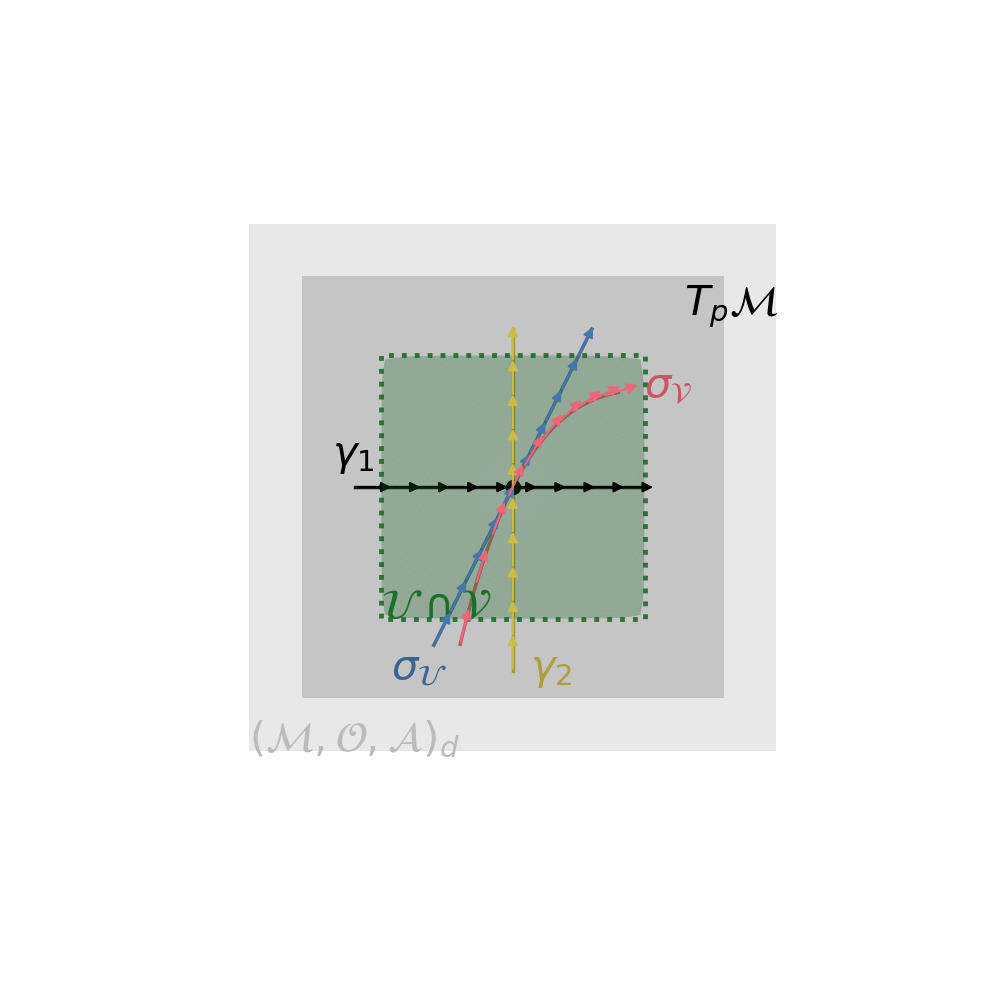

In [5]:
fig = plt.figure(figsize=(10, 10))
ax = fig.add_subplot(111, projection='3d')

plot_manifolds.plot_manifold(
    ax=ax, manifold=manifold, resolution=100, xmin=-1, xmax=3, ymin=-1, ymax=3,
    color=colors[-1], alpha=0.2, edgecolor="none", label=r"$\left(\mathcal{M}, \mathcal{O}, \mathcal{A}\right)_d$",
    label_position="left", label_fontsize=30, function=None, cmap="viridis", label_function="Scalar field $f$",
)

param_pts = jnp.array([[p_x, p_y]])
embedded = manifold.embed(param_pts)
jacobians = manifold.derivatives_at_params(param_pts)
labels = [r"$T_p\mathcal{M}$"]
ax.scatter(embedded[:, 0], embedded[:, 1], embedded[:, 2], color="k", s=100)
plot_manifolds.plot_tangent_spaces(
    ax=ax, embedded_points=embedded, jacobians=jacobians, size=1.6, colors='k',
    alpha=0.15, resolution=10, line_width=2.0, labels=labels, label_fontsize=30, label_offset=0.8
)

# plot_charts.plot_chart_region_manifold(
#     ax=ax, surface_manifold=manifold, chart=chart_U,
#     color=colors[0], n_points=2**11, linestyle="dashed", linewidth=1.5,
#     fill_surface=True, alpha=0.15, edgecolor=None, linewidth_fill=0.5,
#     label=r"$\mathcal{U}$", label_position="bottom", label_fontsize=30,
#     draw_endpoints=True, endpoint_color=colors[0], endpoint_size=30,
# )
# plot_charts.plot_chart_region_manifold(
#     ax=ax, surface_manifold=manifold, chart=chart_V,
#     color=colors[1], n_points=2**12, linestyle="dashed", linewidth=1.5,
#     fill_surface=True, alpha=0.15, edgecolor=None, linewidth_fill=0.5,
#     label=r"$\mathcal{V}$", label_position="bottom", label_fontsize=30,
#     draw_endpoints=True, endpoint_color=colors[1], endpoint_size=30,
# )
plot_charts.plot_chart_region_manifold(
    ax=ax, surface_manifold=manifold, chart=chart_U_cap_V_X,
    color=colors[2], n_points=2**12, linestyle="dotted", linewidth=3.5,
    fill_surface=True, alpha=0.3, edgecolor=None, linewidth_fill=0.5,
    label=r"$\mathcal{U} \cap \mathcal{V}$", label_position="left", label_fontsize=30,
    draw_endpoints=True, endpoint_color=colors[2], endpoint_size=30,
)

plot_curves.plot_curve_on_manifold(
    ax=ax, curve=curve_gamma1, lambda_range=lambda_range_gamma1, n_points=300,
    color="k", linewidth=2.5, label=r"$\gamma_1$", label_position="start", label_fontsize=30, label_offset=(-0.4, 0.2, -0.2)
)
plot_curves.plot_curve_on_manifold(
    ax=ax, curve=curve_gamma2, lambda_range=lambda_range_gamma2, n_points=300,
    color=colors[3], linewidth=2.5, label=r"$\gamma_2$", label_position="start", label_fontsize=30, label_offset=(0.1, 0.3, 0.3)
)
plot_curves.plot_curve_on_manifold(
    ax=ax, curve=curve_sigma_U, lambda_range=lambda_range_sigma_U, n_points=300,
    color=colors[0], linewidth=2.5, label=r"$\sigma_{\mathcal{U}}$", label_position="start", label_fontsize=30, label_offset=(-0.1, 0.1, 0.3)
)
plot_curves.plot_curve_on_manifold(
    ax=ax, curve=curve_sigma_V, lambda_range=lambda_range_sigma_V, n_points=300,
    color=colors[1], linewidth=2.5, label=r"$\sigma_{\mathcal{V}}$", label_position="end", label_fontsize=30, label_offset=(-0.05, -0.2, 0.3)
)

plot_curves.plot_curve_tangents_on_manifold(
    ax=ax, curve=curve_gamma1, lambda_range=lambda_range_gamma1, n_points=300,
    n_arrows=10, color="k", scale=0.3, linewidth=1.5, arrowstyle="-|>",
    mutation_scale=15, alpha=1.0, label=None, label_fontsize=12, label_offset=(0.0, 0.0, 0.0)
)
plot_curves.plot_curve_tangents_on_manifold(
    ax=ax, curve=curve_gamma2, lambda_range=lambda_range_gamma2, n_points=300,
    n_arrows=10, color=colors[3], scale=0.3, linewidth=1.5, arrowstyle="-|>",
    mutation_scale=15, alpha=1.0, label=None, label_fontsize=12, label_offset=(0.0, 0.0, 0.0)
)
plot_curves.plot_curve_tangents_on_manifold(
    ax=ax, curve=curve_sigma_U, lambda_range=lambda_range_sigma_U, n_points=300,
    n_arrows=10, color=colors[0], scale=0.3, linewidth=1.5, arrowstyle="-|>",
    mutation_scale=15, alpha=1.0, label=None, label_fontsize=12, label_offset=(0.0, 0.0, 0.0)
)
plot_curves.plot_curve_tangents_on_manifold(
    ax=ax, curve=curve_sigma_V, lambda_range=lambda_range_sigma_V, n_points=300,
    n_arrows=10, color=colors[1], scale=0.3, linewidth=1.5, arrowstyle="-|>",
    mutation_scale=15, alpha=1.0, label=None, label_fontsize=12, label_offset=(0.0, 0.0, 0.0)
)

ax.view_init(elev=90.0, azim=-90.0)
ax.set_box_aspect([1, 1, 0.8])
plt.tight_layout()
plt.show()

fig.savefig("../saved_figures_and_videos/"+"Fig_TpM_Example_manifold.pdf")

## Chart $(\mathcal{U}, \mathcal{X})$

In [6]:
import matplotlib.patheffects as path_effects

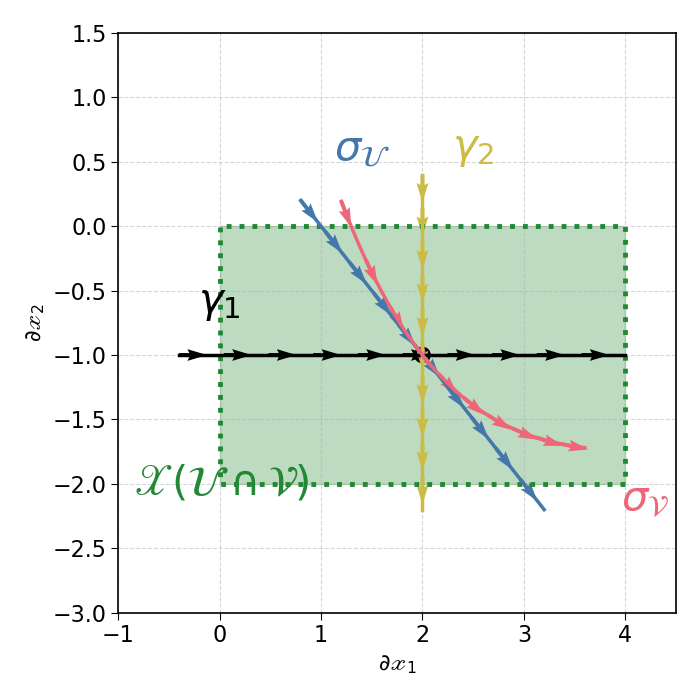

In [7]:
fig, ax = plt.subplots(figsize=(7, 7))

# plot_charts.plot_parametric_region_in_chart_coordinates(
#     ax=ax, chart=chart_U, param_space_data=chart_U.boundary_curve, color=colors[0], linestyle="dashed",
#     linewidth=1.5, alpha=0.3, label=r"$\mathscr{X}(\mathcal{U})$", label_position="bottom",
#     label_fontsize=30, tessellated=False, simplices=None, tessellation_edgecolor="none", tessellation_linewidth=0.1,
#     mark_boundary_points=False, boundary_marker_color=colors[0], boundary_marker_size=8
# )
# plot_charts.plot_parametric_region_in_chart_coordinates(
#     ax=ax, chart=chart_U, param_space_data=chart_V.boundary_curve, color=colors[1], linestyle="dashed",
#     linewidth=1.5, alpha=0.3, label=r"$\mathscr{X}(\mathcal{V})$", label_position="right",
#     label_fontsize=30, tessellated=False, simplices=None, tessellation_edgecolor="none", tessellation_linewidth=0.1,
#     mark_boundary_points=False, boundary_marker_color=colors[1], boundary_marker_size=8
# )
plot_charts.plot_parametric_region_in_chart_coordinates(
    ax=ax, chart=chart_U, param_space_data=chart_U_cap_V_X.boundary_curve, color=colors[2], linestyle="dotted",
    linewidth=3.5, alpha=0.3, label=r"$\mathscr{X}(\mathcal{U} \cap \mathcal{V})$", label_position="bottom",
    label_fontsize=30, tessellated=False, simplices=None, tessellation_edgecolor="none", tessellation_linewidth=0.1,
    mark_boundary_points=False, boundary_marker_color=colors[2], boundary_marker_size=8
)

p_in_chart = chart_U.map_to_chart(p_param)
ax.scatter(
    p_in_chart[0], p_in_chart[1],
    color="k", s=100, edgecolor="k", label=r"$\mathcal{P} \in \mathcal{U}$",
    path_effects=[path_effects.Stroke(linewidth=2, foreground='black'), path_effects.Normal()]
)

plot_curves.plot_curve_in_chart(
    ax=ax, curve=curve_gamma1, chart=chart_U, lambda_range=lambda_range_gamma1, n_points=300,
    color="k", linewidth=2.5, label=r"$\gamma_1$", label_position="start", label_fontsize=30, label_offset=(0.4, 0.4)
)
plot_curves.plot_curve_in_chart(
    ax=ax, curve=curve_gamma2, chart=chart_U, lambda_range=lambda_range_gamma2, n_points=300,
    color=colors[3], linewidth=2.5, label=r"$\gamma_2$", label_position="start", label_fontsize=30, label_offset=(0.5, 0.2)
)
plot_curves.plot_curve_in_chart(
    ax=ax, curve=curve_sigma_U, chart=chart_U, lambda_range=lambda_range_sigma_U, n_points=300,
    color=colors[0], linewidth=2.5, label=r"$\sigma_{\mathcal{U}}$", label_position="start", label_fontsize=30, label_offset=(0.6, 0.4)
)
plot_curves.plot_curve_in_chart(
    ax=ax, curve=curve_sigma_V, chart=chart_U, lambda_range=lambda_range_sigma_V, n_points=300,
    color=colors[1], linewidth=2.5, label=r"$\sigma_{\mathcal{V}}$", label_position="end", label_fontsize=30, label_offset=(0.6, -0.4)
)
plot_curves.plot_curve_tangents_in_chart(
    ax=ax, curve=curve_gamma1, chart=chart_U, lambda_range=lambda_range_gamma1, n_points=500,
    n_arrows=10, color="k", scale=20, width=0.007, label=None, label_fontsize=30, label_offset=(0.05, 0.05)
)
plot_curves.plot_curve_tangents_in_chart(
    ax=ax, curve=curve_gamma2, chart=chart_U, lambda_range=lambda_range_gamma2, n_points=500, n_arrows=10,
    color=colors[3], scale=20, width=0.007, label=None, label_fontsize=30, label_offset=(-0.05, 0.05)
)
plot_curves.plot_curve_tangents_in_chart(
    ax=ax, curve=curve_sigma_U, chart=chart_U, lambda_range=lambda_range_sigma_U, n_points=500, n_arrows=10,
    color=colors[0], scale=20, width=0.007, label=None, label_fontsize=30, label_offset=(0.05, 0.05)
)
plot_curves.plot_curve_tangents_in_chart(
    ax=ax, curve=curve_sigma_V, chart=chart_U, lambda_range=lambda_range_sigma_V, n_points=500, n_arrows=10,
    color=colors[1], scale=20, width=0.007, label=None, label_fontsize=30, label_offset=(0.05, 0.05)
)

ax.set(xlim=(-1., 4.5), ylim=(-3.0, 1.5), xlabel=r"$\partial\mathscr{x}_1$", ylabel=r"$\partial\mathscr{x}_2$")
ax.grid(True, linestyle="--", alpha=0.5)
plt.tight_layout()
plt.show()

fig.savefig("../saved_figures_and_videos/"+"Fig_TpM_Example_U.pdf")

## Chart $(\mathcal{V}, \mathcal{Y})$

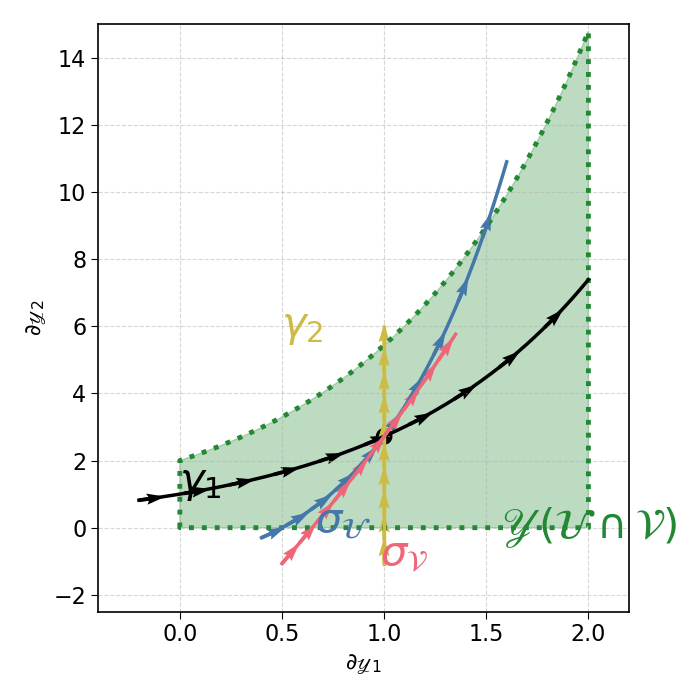

In [8]:
fig, ax = plt.subplots(figsize=(7, 7))

# param_points = jnp.array(chart_U.sample_region_in_param_space(n_points=2**13))
# tri = Delaunay(param_points)
# plot_charts.plot_parametric_region_in_chart_coordinates(
#     ax=ax, chart=chart_V, param_space_data=param_points, color=colors[0], linestyle="dashed",
#     linewidth=1.5, alpha=0.3, label=r"$\mathscr{Y}(\mathcal{U})$", label_position="bottom",
#     label_fontsize=30, tessellated=True, simplices=tri.simplices, tessellation_edgecolor="none", tessellation_linewidth=0.1,
#     mark_boundary_points=False, boundary_marker_color=colors[0], boundary_marker_size=8
# )
# param_points = jnp.array(chart_V.sample_region_in_param_space(n_points=2**13))
# tri = Delaunay(param_points)
# plot_charts.plot_parametric_region_in_chart_coordinates(
#     ax=ax, chart=chart_V, param_space_data=param_points, color=colors[1], linestyle="dashed",
#     linewidth=1.5, alpha=0.3, label=r"$\mathscr{Y}(\mathcal{V})$", label_position="right",
#     label_fontsize=30, tessellated=True, simplices=tri.simplices, tessellation_edgecolor="none", tessellation_linewidth=0.1,
#     mark_boundary_points=False, boundary_marker_color=colors[1], boundary_marker_size=8
# )
plot_charts.plot_parametric_region_in_chart_coordinates(
    ax=ax, chart=chart_V, param_space_data=chart_U_cap_V_Y.boundary_curve, color=colors[2], linestyle="dotted",
    linewidth=3.5, alpha=0.3, label=r"$\mathscr{Y}(\mathcal{U} \cap \mathcal{V})$", label_position="bottom",
    label_fontsize=30, tessellated=False, simplices=None, tessellation_edgecolor="none", tessellation_linewidth=0.1,
    mark_boundary_points=False, boundary_marker_color=colors[2], boundary_marker_size=8
)

# the exponential in Y stretches gamma_2 and sigma_V out of this window at both ends:
# shorter parameter ranges keep them (and their labels) inside it
lambda_range_gamma2_Y = (-0.2, 1.1)
lambda_range_sigma_V_Y = (-0.5, 0.35)

p_in_chart = chart_V.map_to_chart(p_param)
ax.scatter(
    p_in_chart[0], p_in_chart[1],
    color="k", s=100, edgecolor="k", label=r"$\mathcal{P} \in \mathcal{U}$",
    path_effects=[path_effects.Stroke(linewidth=2, foreground='black'), path_effects.Normal()]
)

plot_curves.plot_curve_in_chart(
    ax=ax, curve=curve_gamma1, chart=chart_V, lambda_range=lambda_range_gamma1, n_points=300,
    color="k", linewidth=2.5, label=r"$\gamma_1$", label_position="start", label_fontsize=30, label_offset=(0.3, 0.5)
)
plot_curves.plot_curve_in_chart(
    ax=ax, curve=curve_gamma2, chart=chart_V, lambda_range=lambda_range_gamma2_Y, n_points=300,
    color=colors[3], linewidth=2.5, label=r"$\gamma_2$", label_position="end", label_fontsize=30, label_offset=(-0.4, 0.0)
)
plot_curves.plot_curve_in_chart(
    ax=ax, curve=curve_sigma_U, chart=chart_V, lambda_range=lambda_range_sigma_U, n_points=300,
    color=colors[0], linewidth=2.5, label=r"$\sigma_{\mathcal{U}}$", label_position="start", label_fontsize=30, label_offset=(0.4, 0.5)
)
plot_curves.plot_curve_in_chart(
    ax=ax, curve=curve_sigma_V, chart=chart_V, lambda_range=lambda_range_sigma_V_Y, n_points=300,
    color=colors[1], linewidth=2.5, label=r"$\sigma_{\mathcal{V}}$", label_position="start", label_fontsize=30, label_offset=(0.6, 0.3)
)
plot_curves.plot_curve_tangents_in_chart(
    ax=ax, curve=curve_gamma1, chart=chart_V, lambda_range=lambda_range_gamma1, n_points=500, n_arrows=10,
    color="k", scale=20, width=0.007, label=None, label_fontsize=30, label_offset=(0.05, 0.05)
)
plot_curves.plot_curve_tangents_in_chart(
    ax=ax, curve=curve_gamma2, chart=chart_V, lambda_range=lambda_range_gamma2_Y, n_points=500, n_arrows=10,
    color=colors[3], scale=20, width=0.007, label=None, label_fontsize=30, label_offset=(-0.05, 0.05)
)
plot_curves.plot_curve_tangents_in_chart(
    ax=ax, curve=curve_sigma_U, chart=chart_V, lambda_range=lambda_range_sigma_U, n_points=500, n_arrows=10,
    color=colors[0], scale=20, width=0.007, label=None, label_fontsize=30, label_offset=(0.05, 0.05)
)
plot_curves.plot_curve_tangents_in_chart(
    ax=ax, curve=curve_sigma_V, chart=chart_V, lambda_range=lambda_range_sigma_V_Y, n_points=500, n_arrows=10,
    color=colors[1], scale=20, width=0.007, label=None, label_fontsize=30, label_offset=(0.05, 0.05)
)

# window centred near Y(p) = (1, e), with equal spans so that the tangent arrows keep their directions
ax.set(xlim=(-0.4, 2.2), ylim=(-2.5, 15.0), xlabel=r"$\partial\mathscr{y}_1$", ylabel=r"$\partial\mathscr{y}_2$")
# (the polar chart of the original notebook excluded r < 0 and |theta| > pi; the chart Y here
#  is a global chart, Y(M) = R^2, so there is no excluded region to shade)
# ax.axvspan(-1, 0, color='grey', alpha=0.2, hatch='//')
# ax.axhspan(jnp.pi, jnp.pi+1, color='grey', alpha=0.2, hatch='//')
# ax.axhspan(-jnp.pi-1, -jnp.pi, color='grey', alpha=0.2, hatch='//')
# ax.axhline(jnp.pi, color='gray', ls='--', lw=1)
# ax.axhline(-jnp.pi, color='gray', ls='--', lw=1)
# ax.axvline(0, color='gray', ls='--', lw=1)
ax.grid(True, ls="--", alpha=0.5)
plt.tight_layout()
plt.show()

fig.savefig("../saved_figures_and_videos/"+"Fig_TpM_Example_V.pdf")